# Portfolio Construction — Data Explorer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet('../data/portfolio.parquet')
btc = df[df.symbol == 'BTC'].copy()
eth = df[df.symbol == 'ETH'].copy()

## Schema

In [2]:
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.dtypes

Rows: 13602, Columns: ['timestamp', 'symbol', 'funding_rate', 'realized_vol_30d', 'signal', 'weight', 'turnover', 'cost']


timestamp           datetime64[ns, UTC]
symbol                           object
funding_rate                    float64
realized_vol_30d                float64
signal                            int64
weight                          float64
turnover                        float64
cost                            float64
dtype: object

## First & last rows

In [3]:
btc.head(10)

,timestamp,symbol,funding_rate,realized_vol_30d,signal,weight,turnover,cost
0,2020-01-16 00:00:00+00:00,BTC,0.000100,0.581592,0,0.000000,0.000000,0.000000e+00
2,2020-01-16 08:00:00+00:00,BTC,0.000412,0.579386,1,0.543571,0.543571,5.435706e-04
4,2020-01-16 16:00:00+00:00,BTC,0.000315,0.575758,1,0.544274,0.000703,7.034199e-07
6,2020-01-17 00:00:00+00:00,BTC,0.000100,0.571490,0,0.000000,0.544274,5.442740e-04
8,2020-01-17 08:00:00+00:00,BTC,0.000150,0.569149,1,1.000000,1.000000,1.000000e-03
10,2020-01-17 16:00:00+00:00,BTC,0.000567,0.569727,1,0.551118,0.448882,4.488818e-04
12,2020-01-18 00:00:00.001000+00:00,BTC,0.000100,0.566259,0,0.000000,0.551118,5.511182e-04
14,2020-01-18 08:00:00.001000+00:00,BTC,0.000292,0.563364,1,1.000000,1.000000,1.000000e-03
16,2020-01-18 16:00:00+00:00,BTC,0.000321,0.558539,1,0.562497,0.437503,4.375031e-04
18,2020-01-19 00:00:00+00:00,BTC,0.000200,0.554851,1,0.564452,0.001955,1.955104e-06


In [4]:
btc.tail(10)

,timestamp,symbol,funding_rate,realized_vol_30d,signal,weight,turnover,cost
13582,2026-03-28 16:00:00+00:00,BTC,-1.730000e-06,0.647729,0,0.0,0.0,0.0
13584,2026-03-29 00:00:00.003000+00:00,BTC,-3.680000e-05,0.647729,0,0.0,0.0,0.0
13586,2026-03-29 08:00:00.001000+00:00,BTC,-1.200000e-07,0.647729,0,0.0,0.0,0.0
13588,2026-03-29 16:00:00+00:00,BTC,2.677000e-05,0.647729,0,0.0,0.0,0.0
13590,2026-03-30 00:00:00+00:00,BTC,3.000000e-06,0.647729,0,0.0,0.0,0.0
13592,2026-03-30 08:00:00.005000+00:00,BTC,4.920000e-06,0.647729,0,0.0,0.0,0.0
13594,2026-03-30 16:00:00+00:00,BTC,7.580000e-06,0.647729,0,0.0,0.0,0.0
13596,2026-03-31 00:00:00+00:00,BTC,1.160000e-06,0.647729,0,0.0,0.0,0.0
13598,2026-03-31 08:00:00+00:00,BTC,-1.921000e-05,0.647729,0,0.0,0.0,0.0
13600,2026-03-31 16:00:00+00:00,BTC,-2.763000e-05,0.647729,0,0.0,0.0,0.0


## Coverage & nulls

In [5]:
for name, sub in [('BTC', btc), ('ETH', eth)]:
    print(f"{name}: {len(sub)} periods, {sub['timestamp'].min()} → {sub['timestamp'].max()}")
    print(f"  Null weight: {sub['weight'].isna().sum()}")
    print(f"  Null cost:   {sub['cost'].isna().sum()}")
    active = (sub['weight'] > 0).sum()
    print(f"  Active: {active}/{len(sub)} ({active/len(sub)*100:.1f}%)")
print(f"\nTotal rows: {len(df)}")

BTC: 6801 periods, 2020-01-16 00:00:00+00:00 → 2026-03-31 16:00:00+00:00
  Null weight: 0
  Null cost:   0
  Active: 1041/6801 (15.3%)
ETH: 6801 periods, 2020-01-16 00:00:00+00:00 → 2026-03-31 16:00:00+00:00
  Null weight: 0
  Null cost:   0
  Active: 1223/6801 (18.0%)

Total rows: 13602


## Weight distribution

Inverse-vol sizing: lower vol → higher weight. When both assets are active, weights sum to 1.

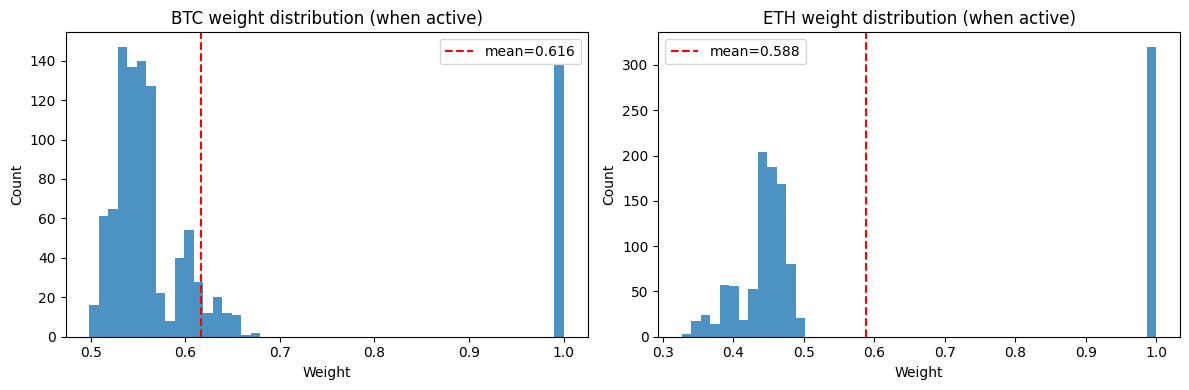

BTC: mean=0.616  median=0.557  min=0.499  max=1.000
ETH: mean=0.588  median=0.461  min=0.327  max=1.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    active = sub.loc[sub['weight'] > 0, 'weight']
    ax.hist(active, bins=50, edgecolor='none', alpha=0.8)
    ax.axvline(active.mean(), color='red', ls='--', label=f'mean={active.mean():.3f}')
    ax.set_title(f'{name} weight distribution (when active)')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()

for name, sub in [('BTC', btc), ('ETH', eth)]:
    active = sub.loc[sub['weight'] > 0, 'weight']
    print(f"{name}: mean={active.mean():.3f}  median={active.median():.3f}  "
          f"min={active.min():.3f}  max={active.max():.3f}")

## Weight allocation over time

How portfolio weight shifts between BTC and ETH based on relative vol.

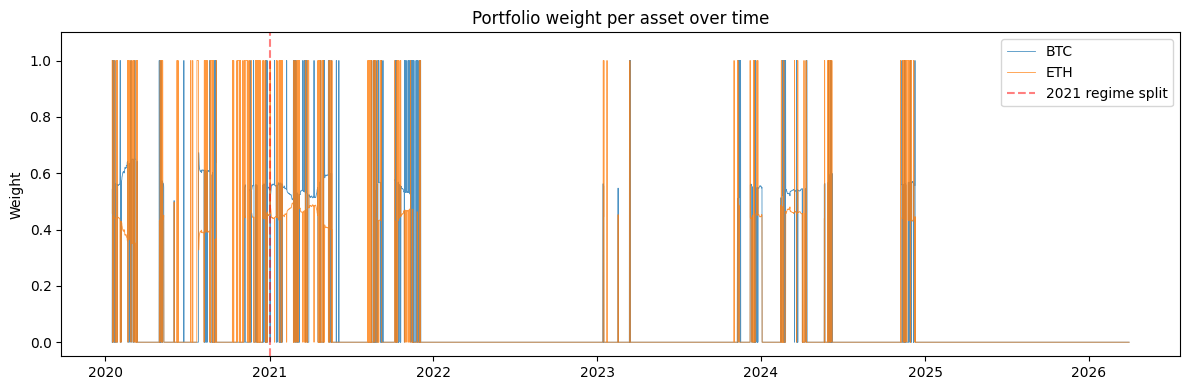

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, sub in [('BTC', btc), ('ETH', eth)]:
    ts = sub.set_index('timestamp')['weight']
    ax.plot(ts.index, ts.values, linewidth=0.6, alpha=0.8, label=name)
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 regime split')
ax.set_ylabel('Weight')
ax.set_title('Portfolio weight per asset over time')
ax.legend()
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

## BTC weight share when both active

When both assets have signal ON, what fraction goes to BTC? (>0.5 means BTC gets more weight = lower vol)

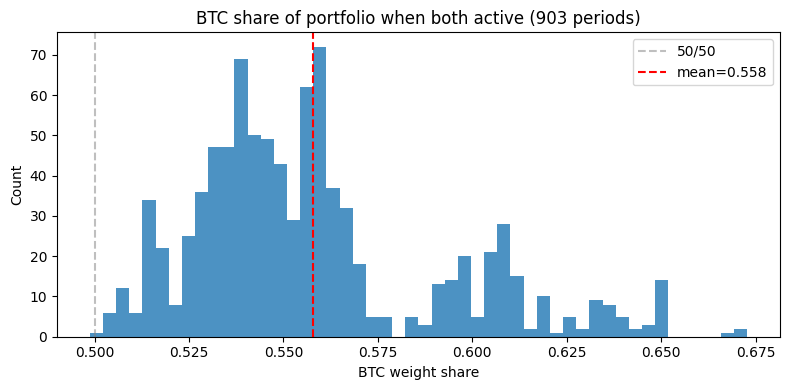

BTC share: mean=0.558  median=0.551
Vol ratio (ETH/BTC): mean=1.252


In [8]:
both = btc.merge(eth, on='timestamp', suffixes=('_btc', '_eth'))
both_active = both[(both['weight_btc'] > 0) & (both['weight_eth'] > 0)].copy()
btc_share = both_active['weight_btc']  # weights sum to 1, so btc weight = btc share

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(btc_share, bins=50, edgecolor='none', alpha=0.8)
ax.axvline(0.5, color='grey', ls='--', alpha=0.5, label='50/50')
ax.axvline(btc_share.mean(), color='red', ls='--', label=f'mean={btc_share.mean():.3f}')
ax.set_xlabel('BTC weight share')
ax.set_ylabel('Count')
ax.set_title(f'BTC share of portfolio when both active ({len(both_active)} periods)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"BTC share: mean={btc_share.mean():.3f}  median={btc_share.median():.3f}")
print(f"Vol ratio (ETH/BTC): mean={both_active['realized_vol_30d_eth'].mean() / both_active['realized_vol_30d_btc'].mean():.3f}")

## Turnover analysis

Turnover = |change in weight| per period. Driven by entries, exits, and vol rebalancing.

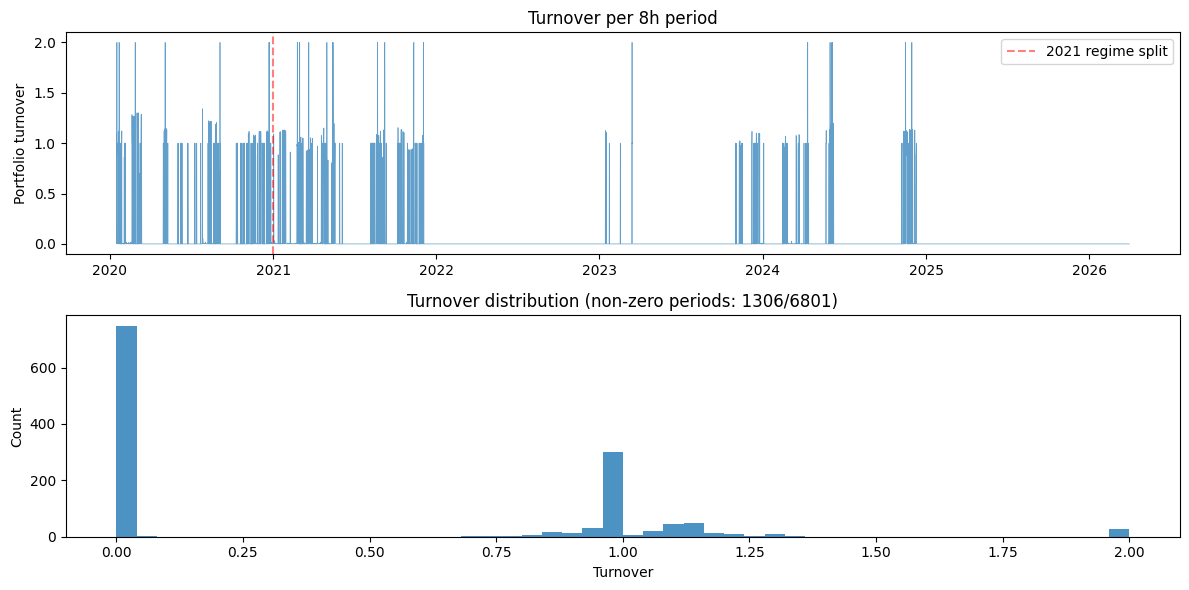

Mean turnover: 0.0876
Mean turnover (non-zero): 0.4559
Periods with trades: 1306/6801 (19.2%)


In [9]:
# Per-period portfolio turnover (sum across assets)
port_turnover = df.groupby('timestamp')['turnover'].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Time series of turnover
ax = axes[0]
ax.plot(port_turnover.index, port_turnover.values, linewidth=0.5, alpha=0.7)
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 regime split')
ax.set_ylabel('Portfolio turnover')
ax.set_title('Turnover per 8h period')
ax.legend()

# Distribution of non-zero turnover
ax = axes[1]
nz = port_turnover[port_turnover > 0]
ax.hist(nz, bins=50, edgecolor='none', alpha=0.8)
ax.set_xlabel('Turnover')
ax.set_ylabel('Count')
ax.set_title(f'Turnover distribution (non-zero periods: {len(nz)}/{len(port_turnover)})')
plt.tight_layout()
plt.show()

print(f"Mean turnover: {port_turnover.mean():.4f}")
print(f"Mean turnover (non-zero): {nz.mean():.4f}")
print(f"Periods with trades: {len(nz)}/{len(port_turnover)} ({len(nz)/len(port_turnover)*100:.1f}%)")

## Trade events — entries vs exits vs rebalances

In [10]:
for name, sub in [('BTC', btc), ('ETH', eth)]:
    prev_w = sub['weight'].shift(1).fillna(0.0)
    entries = ((sub['weight'].values > 0) & (prev_w.values == 0)).sum()
    exits = ((sub['weight'].values == 0) & (prev_w.values > 0)).sum()
    rebalances = ((sub['turnover'].values > 0) & (sub['weight'].values > 0) & (prev_w.values > 0)).sum()
    holds = (sub['turnover'].values == 0).sum()
    print(f"{name}:")
    print(f"  Entries:     {entries:>5d}")
    print(f"  Exits:       {exits:>5d}")
    print(f"  Rebalances:  {rebalances:>5d}")
    print(f"  Holds:       {holds:>5d}")
    print()

BTC:
  Entries:       162
  Exits:         162
  Rebalances:    836
  Holds:        5641

ETH:
  Entries:       161
  Exits:         161
  Rebalances:    906
  Holds:        5573



## Cost analysis

Cost = turnover * 2 * spread_bps / 10,000. Default spread = 5 bps per instrument per direction.

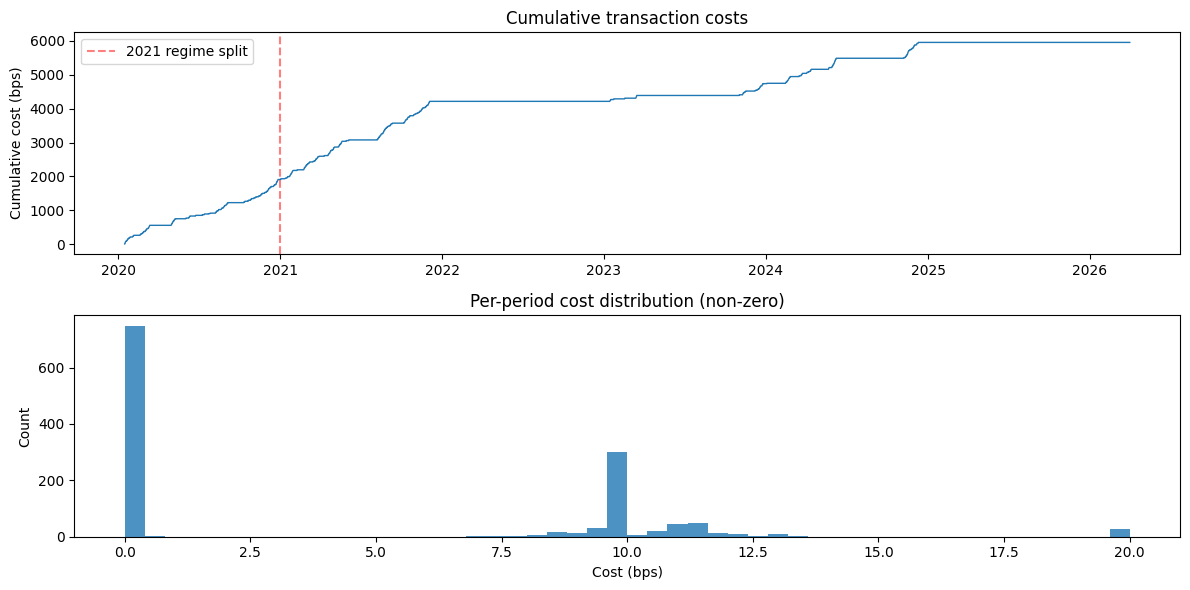

Total cost: 5954.6 bps
Mean cost per period: 0.88 bps
Mean cost per trade period: 4.56 bps


In [11]:
port_cost = df.groupby('timestamp')['cost'].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Cumulative cost over time
ax = axes[0]
cum_cost = port_cost.cumsum() * 10_000
ax.plot(cum_cost.index, cum_cost.values, linewidth=1)
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 regime split')
ax.set_ylabel('Cumulative cost (bps)')
ax.set_title('Cumulative transaction costs')
ax.legend()

# Per-period cost distribution
ax = axes[1]
nz_cost = port_cost[port_cost > 0] * 10_000
ax.hist(nz_cost, bins=50, edgecolor='none', alpha=0.8)
ax.set_xlabel('Cost (bps)')
ax.set_ylabel('Count')
ax.set_title(f'Per-period cost distribution (non-zero)')
plt.tight_layout()
plt.show()

print(f"Total cost: {port_cost.sum()*10_000:.1f} bps")
print(f"Mean cost per period: {port_cost.mean()*10_000:.2f} bps")
print(f"Mean cost per trade period: {nz_cost.mean():.2f} bps")

## Funding income vs cost drag

Gross funding income = weight * funding_rate per period. Compare to cost to see if carry covers costs.

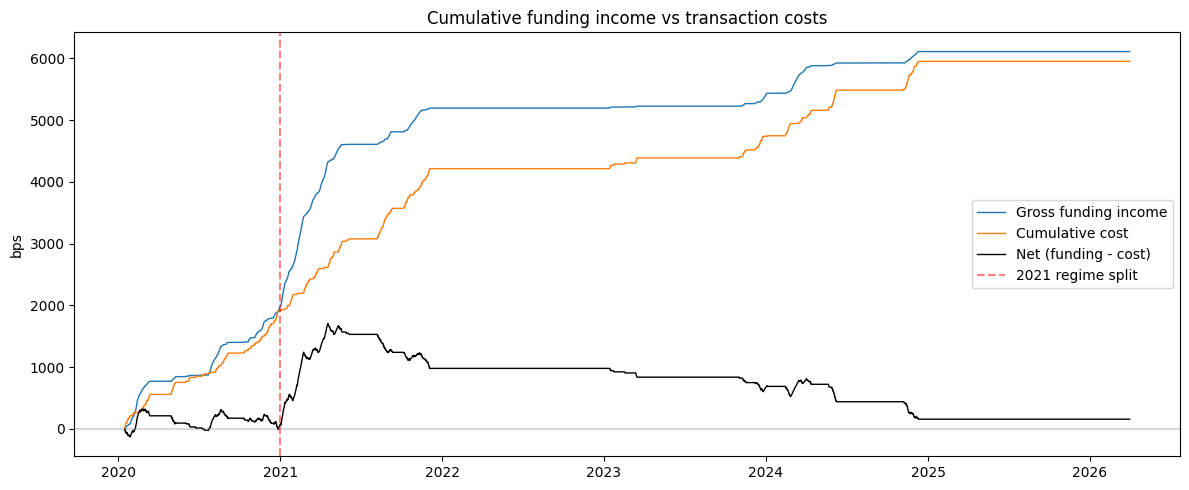

Total funding income: 6111.6 bps
Total cost:           5954.6 bps
Net:                  157.1 bps


In [12]:
df['funding_income'] = df['weight'] * df['funding_rate']
per_ts = df.groupby('timestamp').agg({'funding_income': 'sum', 'cost': 'sum'})

cum_funding = per_ts['funding_income'].cumsum() * 10_000
cum_cost = per_ts['cost'].cumsum() * 10_000
cum_net = cum_funding - cum_cost

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_funding.index, cum_funding.values, label='Gross funding income', linewidth=1)
ax.plot(cum_cost.index, cum_cost.values, label='Cumulative cost', linewidth=1)
ax.plot(cum_net.index, cum_net.values, label='Net (funding - cost)', linewidth=1, color='black')
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 regime split')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set_ylabel('bps')
ax.set_title('Cumulative funding income vs transaction costs')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total funding income: {cum_funding.iloc[-1]:.1f} bps")
print(f"Total cost:           {cum_cost.iloc[-1]:.1f} bps")
print(f"Net:                  {cum_net.iloc[-1]:.1f} bps")

## Spread sensitivity

How total cost and net P&L change across spread assumptions.

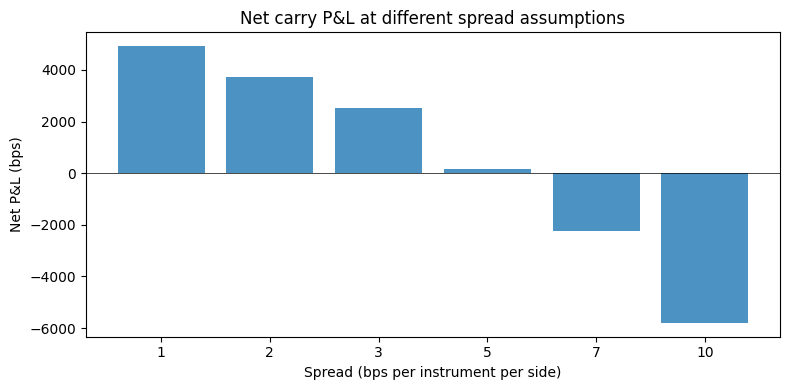

,spread_bps,total_cost_bps,net_bps
0,1,1190.911840,4920.725693
1,2,2381.823680,3729.813853
2,3,3572.735520,2538.902013
3,5,5954.559199,157.078334
4,7,8336.382879,-2224.745346
5,10,11909.118399,-5797.480866


In [13]:
total_funding = per_ts['funding_income'].sum() * 10_000
total_turnover = df['turnover'].sum()

spread_levels = [1, 2, 3, 5, 7, 10]
rows = []
for bps in spread_levels:
    cost = total_turnover * 2 * bps  # turnover * 2 legs * bps
    rows.append({'spread_bps': bps, 'total_cost_bps': cost, 'net_bps': total_funding - cost})
sens = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(b) for b in sens['spread_bps']], sens['net_bps'], alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Spread (bps per instrument per side)')
ax.set_ylabel('Net P&L (bps)')
ax.set_title('Net carry P&L at different spread assumptions')
plt.tight_layout()
plt.show()

sens

## Pre-2021 vs post-2021 comparison

In [14]:
split = pd.Timestamp('2021-01-01', tz='UTC')
rows = []
for name, sub in [('BTC', btc), ('ETH', eth)]:
    for label, mask in [('Pre-2021', sub.timestamp < split), ('Post-2021', sub.timestamp >= split)]:
        s = sub[mask]
        active = (s['weight'] > 0).sum()
        mean_w = s.loc[s['weight'] > 0, 'weight'].mean() if active > 0 else 0
        funding_inc = (s['weight'] * s['funding_rate']).sum() * 10_000
        total_cost = s['cost'].sum() * 10_000
        rows.append({
            'symbol': name, 'regime': label, 'periods': len(s),
            'pct_active': f"{active/len(s)*100:.1f}%",
            'mean_weight': round(mean_w, 3),
            'funding_bps': round(funding_inc, 1),
            'cost_bps': round(total_cost, 1),
            'net_bps': round(funding_inc - total_cost, 1),
        })
pd.DataFrame(rows).set_index(['symbol', 'regime'])

periods pct_active  mean_weight  funding_bps  cost_bps  \
symbol regime                                                              
BTC    Pre-2021      1053      27.4%        0.630        825.7     710.2   
       Post-2021     5748      13.1%        0.611       1969.7    1963.0   
ETH    Pre-2021      1053      38.7%        0.622       1153.8    1200.2   
       Post-2021     5748      14.2%        0.571       2162.5    2081.2   

                  net_bps  
symbol regime              
BTC    Pre-2021     115.4  
       Post-2021      6.7  
ETH    Pre-2021     -46.4  
       Post-2021     81.3

## Yearly portfolio summary

In [15]:
df['year'] = df['timestamp'].dt.year
yearly = df.groupby(['year', 'symbol']).agg(
    periods=('signal', 'count'),
    pct_active=('weight', lambda x: (x > 0).mean() * 100),
    mean_weight=('weight', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    funding_bps=('funding_income', lambda x: x.sum() * 10_000),
    cost_bps=('cost', lambda x: x.sum() * 10_000),
    turnover=('turnover', 'sum'),
).round(1)
yearly['net_bps'] = (yearly['funding_bps'] - yearly['cost_bps']).round(1)
yearly

periods  pct_active  mean_weight  funding_bps  cost_bps  \
year symbol                                                            
2020 BTC        1053        27.4          0.6        825.7     710.2   
     ETH        1053        38.7          0.6       1153.8    1200.2   
2021 BTC        1095        42.9          0.6       1525.4    1105.7   
     ETH        1095        45.4          0.6       1691.1    1199.7   
2022 BTC        1095         0.0          0.0          0.0       0.0   
     ETH        1095         0.0          0.0          0.0       0.0   
2023 BTC        1095         6.3          0.6         99.2     275.4   
     ETH        1095         6.9          0.6        111.3     247.0   
2024 BTC        1098        19.4          0.6        345.1     582.0   
     ETH        1098        22.0          0.6        360.2     634.5   
2025 BTC        1095         0.0          0.0          0.0       0.0   
     ETH        1095         0.0          0.0          0.0       0.0   
2026 BTC         270         0.0          0.0          0.0       0.0   
     ETH         270         0.0          0.0          0.0       0.0   

             turnover  net_bps  
year symbol                     
2020 BTC         71.0    115.5  
     ETH        120.0    -46.4  
2021 BTC        110.6    419.7  
     ETH        120.0    491.4  
2022 BTC          0.0      0.0  
     ETH          0.0      0.0  
2023 BTC         27.5   -176.2  
     ETH         24.7   -135.7  
2024 BTC         58.2   -236.9  
     ETH         63.4   -274.3  
2025 BTC          0.0      0.0  
     ETH          0.0      0.0  
2026 BTC          0.0      0.0  
     ETH          0.0      0.0

## Holding period duration

How long does the strategy stay in each position before exiting?

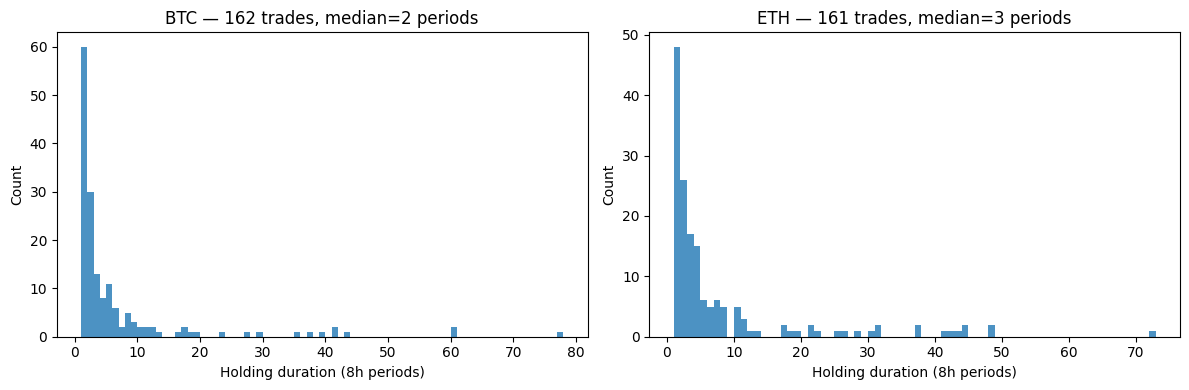

BTC: 162 trades, mean=6.4 periods (51h), median=2, max=77
ETH: 161 trades, mean=7.6 periods (61h), median=3, max=72


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    active = (sub['weight'].values > 0).astype(int)
    # Find run lengths of active periods
    diffs = np.diff(np.concatenate([[0], active, [0]]))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    durations = ends - starts  # in 8h periods

    if len(durations) > 0:
        ax.hist(durations, bins=range(1, min(durations.max() + 2, 100)), edgecolor='none', alpha=0.8)
        ax.set_xlabel('Holding duration (8h periods)')
        ax.set_ylabel('Count')
        ax.set_title(f'{name} — {len(durations)} trades, median={np.median(durations):.0f} periods')
    else:
        ax.set_title(f'{name} — no trades')
plt.tight_layout()
plt.show()

for name, sub in [('BTC', btc), ('ETH', eth)]:
    active = (sub['weight'].values > 0).astype(int)
    diffs = np.diff(np.concatenate([[0], active, [0]]))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    durations = ends - starts
    if len(durations) > 0:
        print(f"{name}: {len(durations)} trades, mean={durations.mean():.1f} periods ({durations.mean()*8:.0f}h), "
              f"median={np.median(durations):.0f}, max={durations.max()}")
    else:
        print(f"{name}: no trades")